# INF2005 steganography demonstration

This notebook sends messages through PNG and WAV carriers. A sender embeds and signs
an encrypted record. Protocol version 3 places `record nonce` and user content inside
the AES-256-GCM record; its RSA-OAEP bootstrap carries the separate `aead nonce`,
session key, and packet geometry. Only the receiver private key can recover the
packet location.

## Setup

`samples/Banana.png` is the cover image. Generated files go to a temporary
directory and are removed at the end.

In [1]:
import os
import struct
import sys
import tempfile
import wave
from datetime import datetime, timezone
from pathlib import Path

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent

def display_path(path: str | Path) -> str:
    path = Path(path)
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)

sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import Audio
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path: str | Path) -> Image.Image:
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview


def show_panels(
    panels: list[tuple[Image.Image, str]],
    scale: int = 1,
    gap: int = 16,
    background: str = "white",
    direction: str = "horizontal",
) -> Image.Image:
    font = ImageFont.load_default()
    prepared = []
    for image, label in panels:
        image = image.convert("RGB")
        image = image.resize((image.width * scale, image.height * scale), Image.Resampling.NEAREST)
        prepared.append((image, str(label)))
    label_height = max(font.getbbox(label)[3] - font.getbbox(label)[1] for _, label in prepared)
    panel_top = label_height + 8
    if direction == "horizontal":
        canvas_width = sum(image.width for image, _ in prepared) + gap * (len(prepared) - 1)
        canvas_height = panel_top + max(image.height for image, _ in prepared) + 2
    elif direction == "vertical":
        canvas_width = max(image.width for image, _ in prepared)
        canvas_height = sum(panel_top + image.height + 2 for image, _ in prepared) + gap * (len(prepared) - 1)
    else:
        raise ValueError("direction must be horizontal or vertical")
    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)
    if direction == "horizontal":
        positions = ((sum(image.width + gap for image, _ in prepared[:index]), panel_top) for index in range(len(prepared)))
    else:
        positions = ((0, panel_top + sum(panel_top + image.height + 2 + gap for image, _ in prepared[:index])) for index in range(len(prepared)))
    for (image, label), (x, y) in zip(prepared, positions):
        draw.text((x, y - panel_top + 2), label, fill="black", font=font)
        panel_y = y
        canvas.paste(image, (x, panel_y))
        draw.rectangle((x, panel_y, x + image.width - 1, panel_y + image.height - 1), outline="black", width=1)
    return canvas

def print_hexdump(data: bytes, start: int = 0, end: int | None = None) -> None:
    end = len(data) if end is None else min(end, len(data))
    for offset in range(start, end, 16):
        chunk = data[offset:min(offset + 16, end)]
        print(f"{offset:04x}: {chunk.hex(' ')}")

print("Temporary demonstration files are kept private.")
print(f"Sample cover: {display_path(sample_png_path)}")

Temporary demonstration files are kept private.
Sample cover: samples/Banana.png


## Sender

The sender loads a cover, chooses embedding settings, signs a message, and writes
a stego file.

### Load the cover image

`PngCarrier` checks the file and reads carrier units in chunks. Pillow decodes the
whole image for display.

Input path: samples/Banana.png
Array shape: (1568, 1280, 3)
Array dtype: uint8
Backend carrier units: 6021120


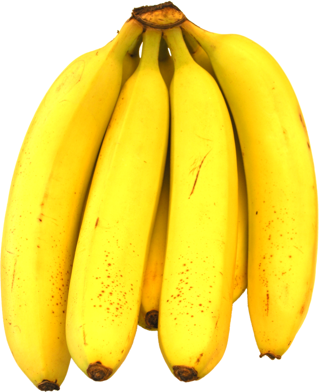

In [2]:
cover_source = PngCarrier(sample_png_path)
with Image.open(sample_png_path) as cover_image_file:
    cover_array = np.asarray(cover_image_file, dtype=np.uint8).copy()
cover_image = Image.fromarray(cover_array, mode="RGB")
cover_display = cover_image.copy()
cover_display.thumbnail((320, 392))
print("Input path:", display_path(sample_png_path))
print("Array shape:", cover_array.shape)
print("Array dtype:", cover_array.dtype)
print("Backend carrier units:", cover_source.total_units)
display(cover_display)

### Choose the message and embedding settings

A carrier unit is one byte used for embedding. The LSB count (`k`) is the number
of low bits used in each unit. The sender chooses a packet start at or after the
2,048-unit RSA-2048 bootstrap span; the bootstrap records the start and `k` for the
receiver. The image provides 6,021,120 carrier units.

In [3]:
private_key: rsa.RSAPrivateKey
public_key: rsa.RSAPublicKey
private_key, public_key = generate_rsa_keypair()
receiver_private_key: rsa.RSAPrivateKey
receiver_public_key: rsa.RSAPublicKey
receiver_private_key, receiver_public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
save_rsa_public_key_pem(public_key, public_key_path)
start_unit = 2997120
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"
cover_width, cover_height, cover_channels = struct.unpack(">IIB", cover_source.media_context)
print(f"Carrier units: {cover_width}*{cover_height}*{cover_channels} = {cover_source.total_units}")
print(f"Capacity at k={lsb_count}: {cover_source.total_units * lsb_count} bits ({cover_source.total_units * lsb_count // 8} bytes before packet overhead)")
print("Start unit:", start_unit)
print("LSB count:", lsb_count)
print("Message bytes:", image_message)
print("Metadata:", image_metadata)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))

Carrier units: 1280*1568*3 = 6021120
Capacity at k=3: 18063360 bits (2257920 bytes before packet overhead)
Start unit: 2997120
LSB count: 3
Message bytes: b'INF2005 end-to-end image demonstration'
Metadata: b'kind=png;flow=sender-receiver'
Public-key fingerprint: SHA256:gLYRCwI9JatSjf0MVzL/lsp6MegUUYNYNdt9QxrWHXI


### Embed the message

`encode_png` writes an AES-256-GCM encrypted record and its RSA-PSS signature, then
writes the RSA-OAEP bootstrap. It returns the layout and the sender-side payload.

In [4]:
png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    receiver_public_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)

### Inspect the packet

Here is what the encoder produced: where the packet sits and what it contains. A
footprint is the range of carrier units used by the packet. The media hash is a
digest of the full media samples, with the bits written by the packet masked out.

In [5]:
print("Layout.start_unit:", png_layout.start_unit)
print("Layout.lsb_count:", png_layout.lsb_count)
print("Layout.ciphertext_length:", png_layout.ciphertext_length)
print("Layout.footprint:", png_layout.footprint)
print("Layout.pad_bits:", png_layout.pad_bits)
print("Payload.media_id:", png_payload.media_id)
print("Payload.timestamp (integer):", png_payload.timestamp)
print("Payload.timestamp (UTC):", datetime.fromtimestamp(png_payload.timestamp, timezone.utc).isoformat())
print("Payload.nonce (hex):", png_payload.nonce.hex())
print("Payload.media_hash (hex):", png_payload.media_hash.hex())
print("Payload.user_payload:", png_payload.user_payload)
print("Payload.metadata:", png_payload.metadata)
png_payload_bytes = serialize_payload(png_payload)
print("Serialized payload hexdump (first 64 and last 16 bytes):")
print_hexdump(png_payload_bytes, 0, 64)
print(f"... [{len(png_payload_bytes) - 80} bytes skipped] ...")
print_hexdump(png_payload_bytes, len(png_payload_bytes) - 16)


Layout.start_unit: 2997120
Layout.lsb_count: 3
Layout.ciphertext_length: 192
Layout.footprint: 1195
Layout.pad_bits: 1
Payload.media_id: IMG-7e1a2ce3c42cc2c0c38a8c3f7d026bd5
Payload.timestamp (integer): 1790303904
Payload.timestamp (UTC): 2026-09-25T02:38:24+00:00
Payload.nonce (hex): 2708046a468e834d86f39e6d29bcf548
Payload.media_hash (hex): 70f5b2a22e6b92a2ff3017ed17497d55039349d67b9e0a38142024c3e2554d12
Payload.user_payload: b'INF2005 end-to-end image demonstration'
Payload.metadata: b'kind=png;flow=sender-receiver'
Serialized payload hexdump (first 64 and last 16 bytes):
0000: 24 49 4d 47 2d 37 65 31 61 32 63 65 33 63 34 32
0010: 63 63 32 63 30 63 33 38 61 38 63 33 66 37 64 30
0020: 32 36 62 64 35 00 00 00 00 6a b5 de a0 27 08 04
0030: 6a 46 8e 83 4d 86 f3 9e 6d 29 bc f5 48 70 f5 b2
... [96 bytes skipped] ...
00a0: 3d 73 65 6e 64 65 72 2d 72 65 63 65 69 76 65 72


### What the signature covers

The signed bytes begin with `INF2005-ACW1\0SIGN\0`. They contain the protocol
version from the sender's constant, media code, LSB count, total units, start unit,
footprint, `ciphertext_length`, media context, and ciphertext. The version comes
from the protocol constant. The recovered geometry is signed, so moving the packet
invalidates the signature even when its encrypted bytes are unchanged.

In [6]:
# Read the signed packet through the PNG backend.
png_stego_source = PngCarrier(stego_png_path)
png_packet_units = png_stego_source.read_units(png_layout.start_unit, png_layout.footprint)
png_packet_bits = read_lsb_bits(png_packet_units, png_layout.footprint * png_layout.lsb_count, png_layout.lsb_count)
png_packet = bit_sequence_to_bytes(png_packet_bits[:(png_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8])
png_ciphertext = png_packet[:png_layout.ciphertext_length]
png_signed_input = encode_signing_input(png_stego_source.media_code, png_stego_source.media_context, png_layout, png_ciphertext)
print("Signed-input length:", len(png_signed_input))
print("Encrypted ciphertext length:", len(png_ciphertext))
print("Signed-input hexdump (first 96 bytes):")
print_hexdump(png_signed_input, 0, 96)

Signed-input length: 254
Encrypted ciphertext length: 192
Signed-input hexdump (first 96 bytes):
0000: 49 4e 46 32 30 30 35 2d 41 43 57 31 00 53 49 47
0010: 4e 00 03 01 03 00 00 00 00 00 5b e0 00 00 00 00
0020: 00 00 2d bb 80 00 00 00 00 00 00 04 ab 00 00 00
0030: 00 00 00 00 c0 00 00 05 00 00 00 06 20 03 c1 bc
0040: 8a a7 2e 5c b1 c7 6a de d3 5c 39 76 18 4c 1b e7
0050: 82 f8 e4 fd 78 e6 89 50 88 a2 bd 24 93 88 e2 a8


### Inspect the written image

The packet table reads units from `PngCarrier`. Pillow loads the images for display.
With `k=3`, only the low three bits may differ. The strip shows the packet window.

Stego file: banana-stego.png
Stego file bytes: 1675274
Differing pixel values: 2066
Cover values across packet footprint: min= 0 max= 255
First 8 carrier units at packet location:
index | cover decimal | cover binary | stego decimal | stego binary
    0 |            130 | 10000010 |            134 | 10000110
    1 |             85 | 01010101 |             80 | 01010000
    2 |              0 | 00000000 |              3 | 00000011
    3 |            118 | 01110110 |            115 | 01110011
    4 |             74 | 01001010 |             78 | 01001110
    5 |              0 | 00000000 |              2 | 00000010
    6 |            115 | 01110011 |            113 | 01110001
    7 |             74 | 01001010 |             74 | 01001010
Packet region: 398 pixels of 2,007,040 (0.02% of the image)
Packet span: row 780, columns 640 to 1037
Zoom window: 422×27 pixels, rows 767 to 793, columns 628 to 1049; full packet with margins


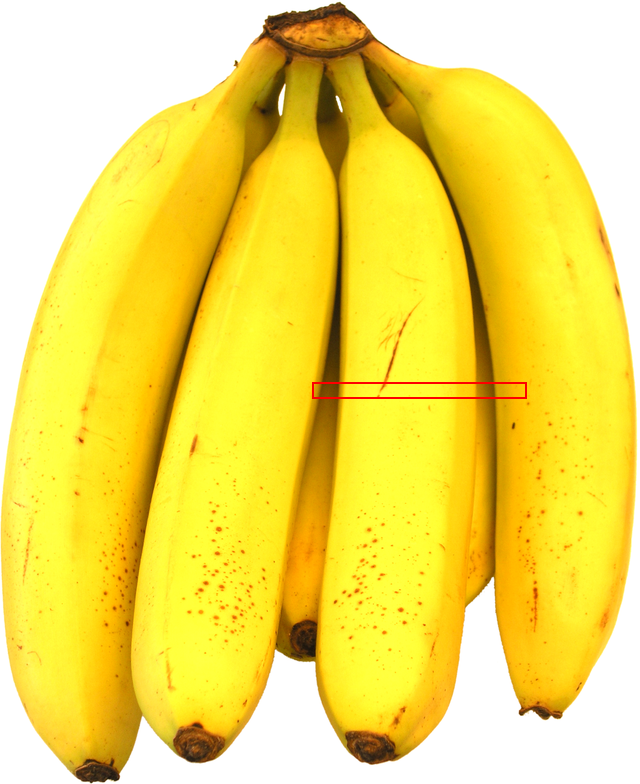

In [7]:
with Image.open(stego_png_path) as stego_image_file:
    stego_array = np.asarray(stego_image_file, dtype=np.uint8).copy()
stego_image = Image.fromarray(stego_array, mode="RGB")
stego_source = PngCarrier(stego_png_path)
packet_cover_units = cover_source.read_units(png_layout.start_unit, png_layout.footprint)
packet_stego_units = stego_source.read_units(png_layout.start_unit, png_layout.footprint)
print("Stego file:", stego_png_path.name)
print("Stego file bytes:", stego_png_path.stat().st_size)
different_values = 0
for unit_start in range(0, cover_source.total_units, 65536):
    unit_count = min(65536, cover_source.total_units - unit_start)
    different_values += int(np.count_nonzero(
        cover_source.read_units(unit_start, unit_count) != stego_source.read_units(unit_start, unit_count)
    ))
print("Differing pixel values:", different_values)
print("Cover values across packet footprint: min=", int(packet_cover_units.min()), "max=", int(packet_cover_units.max()))
print("First 8 carrier units at packet location:")
print("index | cover decimal | cover binary | stego decimal | stego binary")
for offset, (cover_value, stego_value) in enumerate(zip(packet_cover_units[:8], packet_stego_units[:8])):
    print(f"{offset:5d} | {int(cover_value):14d} | {int(cover_value):08b} | {int(stego_value):14d} | {int(stego_value):08b}")

packet_start_pixel = png_layout.start_unit // 3
packet_pixel_count = png_layout.footprint // 3
packet_end_pixel = packet_start_pixel + packet_pixel_count - 1
packet_start_y, packet_start_x = divmod(packet_start_pixel, cover_width)
packet_end_y, packet_end_x = divmod(packet_end_pixel, cover_width)
total_pixel_count = cover_source.total_units // 3
horizontal_margin = 12
vertical_margin = 13
window_box = (
    packet_start_x - horizontal_margin,
    packet_start_y - vertical_margin,
    packet_end_x + horizontal_margin + 1,
    packet_end_y + vertical_margin + 1,
)
window_width = window_box[2] - window_box[0]
window_height = window_box[3] - window_box[1]
whole_image = cover_image.copy()
whole_display = whole_image.resize((640, 784), Image.Resampling.LANCZOS)
display_scale_x = whole_display.width / whole_image.width
display_scale_y = whole_display.height / whole_image.height
display_window_box = (
    round(window_box[0] * display_scale_x) - 2,
    round(window_box[1] * display_scale_y) - 2,
    round(window_box[2] * display_scale_x) + 1,
    round(window_box[3] * display_scale_y) + 1,
)
ImageDraw.Draw(whole_display).rectangle(display_window_box, outline="red", width=2)
print(f"Packet region: {packet_pixel_count:,} pixels of {total_pixel_count:,} ({packet_pixel_count / total_pixel_count:.2%} of the image)")
print(f"Packet span: row {packet_start_y}, columns {packet_start_x} to {packet_end_x}")
print(f"Zoom window: {window_width}×{window_height} pixels, rows {window_box[1]} to {window_box[3] - 1}, columns {window_box[0]} to {window_box[2] - 1}; full packet with margins")
display(whole_display)

### Inspect the packet window

The zoomed panels show the cover, stego image, and changed carrier units.

Full packet strip, stacked at 2x: cover, stego, changed units:


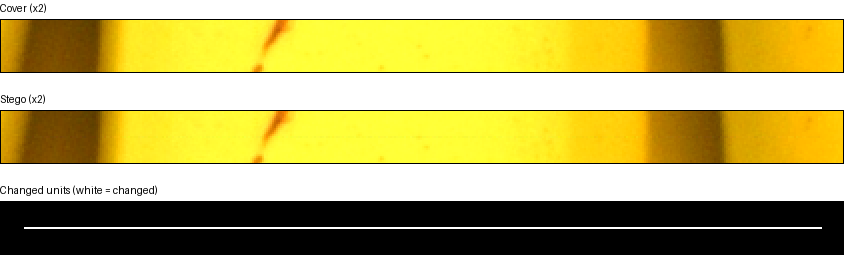

In [8]:
print("Full packet strip, stacked at 2x: cover, stego, changed units:")
cover_crop = cover_image.crop(window_box)
stego_crop = stego_image.crop(window_box)
changed_pixel_mask = np.any(stego_array != cover_array, axis=2)
changed_mask_image = Image.fromarray(np.where(changed_pixel_mask, 255, 0).astype(np.uint8), mode="L")
changed_crop = changed_mask_image.crop(window_box)
display(show_panels([(cover_crop, "Cover (x2)"), (stego_crop, "Stego (x2)"), (changed_crop, "Changed units (white = changed)")], scale=2, direction="vertical"))

### End the sender phase

The sender keeps the signing private key private. The receiver needs the sender
public key and receiver private key; the packet geometry is carried inside the
receiver's RSA-OAEP bootstrap rather than passed as plaintext out of band.

In [9]:
# The receiver needs only the sender public key and receiver private key.
receiver_sender_public_key = public_key
receiver_bootstrap_span = bootstrap_span(receiver_private_key)
del private_key, public_key


## Receiver

The receiver opens the RSA-OAEP bootstrap with the receiver private key, recovers
the packet geometry and session material, then verifies the sender's RSA-PSS
signature and AES-GCM record.

### Files and keys available to the receiver

The receiver has the stego image path, the sender public-key PEM path, and the
receiver private key. No start unit, LSB count, or record length is transported
separately; those values are recovered from the bootstrap.

In [10]:
print("Stego file:", stego_png_path.name)
print("Sender public-key PEM:", public_key_path.name)
receiver_private_key_path = DEMO_DIR / "banana-receiver-private-key.pem"
receiver_private_key_password = b"receiver-demo-password"
save_rsa_private_key_pem(receiver_private_key, receiver_private_key_path, password=receiver_private_key_password)
receiver_private_key = load_rsa_private_key_pem(receiver_private_key_path, password=receiver_private_key_password)
print("Receiver private key loaded from password-protected PEM:", receiver_private_key_path.name)


Stego file: banana-stego.png
Sender public-key PEM: banana-public-key.pem
Receiver private key loaded from password-protected PEM: banana-receiver-private-key.pem


### How the start location is secured

The sender chooses the packet start and LSB count, subject to the start being at or
after the reserved bootstrap span. The sender writes those values, the ciphertext
length, session key, and `aead_nonce` into the RSA-OAEP bootstrap at fixed unit 0.
The receiver reads that one bootstrap with the receiver private key and uses the
recovered geometry to find the same packet.

**Claimed:** without the receiver private key, the packet location cannot be
recovered from protocol structure or locator metadata. The record and geometry
fields are encrypted or authenticated, so unauthorised extraction is refused.

**Not claimed:** the bootstrap is not hidden; its fixed span is observable. Statistical
steganalysis is out of scope. An attacker can overwrite unit 0 and cheaply destroy
extraction; this denial of service does not leave a useful tamper signal.

In [11]:
receiver_geometry = {"bootstrap_span": receiver_bootstrap_span, "location_and_length": "encrypted in the RSA-OAEP bootstrap"}
print("Receiver bootstrap:", receiver_geometry)


Receiver bootstrap: {'bootstrap_span': 2048, 'location_and_length': 'encrypted in the RSA-OAEP bootstrap'}


### Verify the payload

The receiver loads the sender public key and receiver private key, opens the
bootstrap, recovers the geometry, and verifies the stego image. A valid result
returns the media ID, timestamp, and message.

In [12]:
sender_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, sender_public_key, receiver_private_key)
print("PNG verdict:", png_result.verdict)
print("Key fingerprint:", png_result.key_fingerprint)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))


PNG verdict: Authentic
Key fingerprint: SHA256:gLYRCwI9JatSjf0MVzL/lsp6MegUUYNYNdt9QxrWHXI
Media ID: IMG-7e1a2ce3c42cc2c0c38a8c3f7d026bd5
Timestamp: 1790303904
Recovered message: INF2005 end-to-end image demonstration


## RGBA PNG integrity

Protocol version 3 keeps the RGB carrier units and hashes the alpha channel as
fixed media data. It does not change alpha while it writes the packet. This cover
comes from the RGB sample. It has a transparent border and a half-transparent band.


In [13]:
rgba_height, rgba_width = cover_array.shape[:2]
rgba_cover_array = np.empty((rgba_height, rgba_width, 4), dtype=np.uint8)
rgba_cover_array[:, :, :3] = cover_array
rgba_cover_array[:, :, 3] = 255
rgba_border = 16
rgba_cover_array[:rgba_border, :, 3] = 0
rgba_cover_array[-rgba_border:, :, 3] = 0
rgba_cover_array[:, :rgba_border, 3] = 0
rgba_cover_array[:, -rgba_border:, 3] = 0
rgba_band_top = rgba_height // 3
rgba_band_bottom = 2 * rgba_height // 3
rgba_cover_array[rgba_band_top:rgba_band_bottom, :, 3] = 128
rgba_cover_path = DEMO_DIR / "banana-rgba-cover.png"
rgba_stego_path = DEMO_DIR / "banana-rgba-stego.png"
rgba_tampered_path = DEMO_DIR / "banana-rgba-alpha-tampered.png"
Image.fromarray(rgba_cover_array, mode="RGBA").save(rgba_cover_path, format="PNG")
rgba_alpha_before = rgba_cover_array[:, :, 3].copy()
with Image.open(rgba_cover_path) as rgba_image:
    print("RGBA input mode:", rgba_image.mode)
rgba_source = PngCarrier(rgba_cover_path)
print("PngCarrier channel_count:", rgba_source.channel_count)
print("PngCarrier fixed_byte_count:", rgba_source.fixed_byte_count)
print("Expected alpha byte count:", rgba_width * rgba_height)
rgba_sender_private_key, rgba_sender_public_key = generate_rsa_keypair()
rgba_layout, _ = encode_png(
    rgba_cover_path,
    rgba_stego_path,
    rgba_sender_private_key,
    receiver_public_key,
    start_unit=bootstrap_span(receiver_public_key),
    lsb_count=3,
    user_payload=b"RGBA alpha is preserved and hashed",
    metadata=b"kind=png;flow=rgba-demo",
)
rgba_result = verify_png(rgba_stego_path, rgba_sender_public_key, receiver_private_key)
with Image.open(rgba_stego_path) as rgba_stego_image:
    rgba_stego_array = np.asarray(rgba_stego_image, dtype=np.uint8).copy()
    print("RGBA stego mode:", rgba_stego_image.mode)
alpha_unchanged = np.array_equal(rgba_stego_array[:, :, 3], rgba_alpha_before)
print("RGBA verdict:", rgba_result.verdict)
print("Alpha bytes unchanged:", alpha_unchanged)
rgba_tampered_array = rgba_stego_array.copy()
rgba_tampered_array[rgba_height // 2, rgba_width // 2, 3] ^= np.uint8(1)
Image.fromarray(rgba_tampered_array, mode="RGBA").save(rgba_tampered_path, format="PNG")
print(
    "One alpha-byte change verdict:",
    verify_png(rgba_tampered_path, rgba_sender_public_key, receiver_private_key).verdict,
)
del rgba_cover_array, rgba_stego_array, rgba_tampered_array, rgba_sender_private_key


RGBA input mode: RGBA
PngCarrier channel_count: 4
PngCarrier fixed_byte_count: 2007040
Expected alpha byte count: 2007040


RGBA stego mode: RGBA
RGBA verdict: Authentic
Alpha bytes unchanged: True


One alpha-byte change verdict: Tampered


## Failure cases

The matrix below separates sender-authentication failure, receiver-bootstrap failure,
location bounds, decryption failure, and carrier tampering. The untouched cover is
treated as having no readable payload.

### Altered image

Change one carrier unit outside the packet with `PngCarrier`. The signature still
verifies, but the masked media hash reports tampering.

In [14]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_source = PngCarrier(stego_png_path)
def flip_last_image_unit(chunk_start: int, chunk: np.ndarray) -> np.ndarray:
    changed = chunk.copy()
    last_unit = altered_source.total_units - 1
    if chunk_start <= last_unit < chunk_start + chunk.size:
        changed[last_unit - chunk_start] ^= np.uint8(1)
    return changed
altered_source.rewrite_to_path(altered_png_path, flip_last_image_unit)
print("Altered PNG verdict:", verify_png(altered_png_path, sender_public_key, receiver_private_key).verdict)

Altered PNG verdict: Tampered


### Wrong sender public key

A signature made by the sender cannot be verified with an unrelated sender public
key, so this case is `Signature Invalid`.

In [15]:
wrong_sender_private_key: rsa.RSAPrivateKey
wrong_sender_public_key: rsa.RSAPublicKey
wrong_sender_private_key, wrong_sender_public_key = generate_rsa_keypair()
print("Wrong sender-key PNG verdict:", verify_png(stego_png_path, wrong_sender_public_key, receiver_private_key).verdict)
del wrong_sender_private_key, wrong_sender_public_key


Wrong sender-key PNG verdict: Signature Invalid


### Wrong receiver private key

A file addressed to another receiver and a file with no payload are indistinguishable.
Both fail at RSA-OAEP opening and produce `Payload Missing`.

In [16]:
wrong_receiver_private_key: rsa.RSAPrivateKey
wrong_receiver_public_key: rsa.RSAPublicKey
wrong_receiver_private_key, wrong_receiver_public_key = generate_rsa_keypair()
print("Wrong receiver-key PNG verdict:", verify_png(stego_png_path, sender_public_key, wrong_receiver_private_key).verdict)
del wrong_receiver_private_key, wrong_receiver_public_key


Wrong receiver-key PNG verdict: Payload Missing


### Untouched cover

The original cover has no readable RSA-OAEP bootstrap, so verification returns
`Payload Missing`.

In [17]:
print("Untouched cover verdict:", verify_png(sample_png_path, sender_public_key, receiver_private_key).verdict)

Untouched cover verdict: Payload Missing


### Does the raw payload fit?

The raw RGB data is 1280 × 1568 × 3 = 6,021,120 bytes, exactly one byte per
carrier unit. `PngCarrier` reads the units. At `k=8`, the carrier can hold one byte
per unit, but the packet also needs the bootstrap, record, tag, signature, and
alignment. The first refusal is therefore for payload capacity. The small PNG below
shows the separate refusal for a carrier that cannot hold the protocol object.

In [18]:
capacity_source = PngCarrier(sample_png_path)
capacity_payload = capacity_source.read_units(0, capacity_source.total_units).tobytes()
capacity_metadata = b"capacity test"
capacity_at_k8 = capacity_source.total_units
capacity_private_key: rsa.RSAPrivateKey
capacity_receiver_public_key: rsa.RSAPublicKey
capacity_private_key, capacity_receiver_public_key = generate_rsa_keypair()
capacity_span = bootstrap_span(capacity_receiver_public_key)
try:
    capacity_encoding = prepare_carrier_encoding(
        capacity_source, capacity_source.media_code, capacity_source.media_context,
        capacity_private_key, capacity_receiver_public_key, capacity_span, 8,
        capacity_payload, capacity_metadata,
    )
    capacity_result = "Unexpected result: the capacity case was accepted"
except ValueError as error:
    capacity_result = f"Payload-too-large refusal: {error}"
# Make a real small RGB PNG with fewer units than the minimum protocol needs.
capacity_small_path = DEMO_DIR / "capacity-small.png"
Image.new("RGB", (809, 1), (64, 96, 128)).save(capacity_small_path, format="PNG")
capacity_small_source = PngCarrier(capacity_small_path)
capacity_small_refusals = []
for capacity_small_payload in (b"", b"x"):
    try:
        prepare_carrier_encoding(
            capacity_small_source, capacity_small_source.media_code,
            capacity_small_source.media_context, capacity_private_key,
            capacity_receiver_public_key, capacity_span, 8,
            capacity_small_payload, b"",
        )
        capacity_small_refusals.append("Unexpected result: too-small carrier was accepted")
    except ValueError as error:
        capacity_small_refusals.append(str(error))
print(f"Raw RGB payload: {len(capacity_payload):,} bytes")
print(f"Carrier capacity at k=8: {capacity_source.total_units:,} carrier units × 8 bits ÷ 8 = {capacity_at_k8:,} bytes")
print(capacity_result)
print("Too-small-carrier refusal (empty payload):", capacity_small_refusals[0])
print("Too-small-carrier refusal (one-byte payload):", capacity_small_refusals[1])
del capacity_payload, capacity_metadata, capacity_at_k8
del capacity_private_key, capacity_receiver_public_key, capacity_source, capacity_small_source

Raw RGB payload: 6,021,120 bytes
Carrier capacity at k=8: 6,021,120 carrier units × 8 bits ÷ 8 = 6,021,120 bytes
Payload-too-large refusal: user payload exceeds capacity: user_payload_length=6021120, max_user_payload_length=6018678, total_units=6021120, start_unit=2048, lsb_count=8
Too-small-carrier refusal (empty payload): carrier is too small for the protocol: total_units=2427, start_unit=2048, lsb_count=8, minimum_units=2429
Too-small-carrier refusal (one-byte payload): carrier is too small for the protocol: total_units=2427, start_unit=2048, lsb_count=8, minimum_units=2429


### Verdict matrix

Each changed PNG below is written through the file backend. `verify_png` then runs
the normal file-verification path for all seven verdicts.

In [19]:
def bootstrap_fields_from_image(source: PngCarrier) -> BootstrapFields:
    span = bootstrap_span(receiver_private_key)
    bootstrap_units = source.read_units(0, span)
    envelope = bit_sequence_to_bytes(read_lsb_bits(bootstrap_units, span, BOOTSTRAP_LSB_COUNT))
    return parse_bootstrap(open_with_private_key(envelope, receiver_private_key))

def verify_image_file(
    path: Path,
    sender_key: rsa.RSAPublicKey | None = None,
    receiver_key: rsa.RSAPrivateKey | None = None,
) -> str:
    selected_sender = sender_public_key if sender_key is None else sender_key
    selected_receiver = receiver_private_key if receiver_key is None else receiver_key
    return verify_png(path, selected_sender, selected_receiver).verdict

def flip_last_matrix_unit(chunk_start: int, chunk: np.ndarray) -> np.ndarray:
    changed = chunk.copy()
    last_unit = stego_source.total_units - 1
    if chunk_start <= last_unit < chunk_start + chunk.size:
        changed[last_unit - chunk_start] ^= np.uint8(1)
    return changed

stego_source = PngCarrier(stego_png_path)
matrix_fields = bootstrap_fields_from_image(stego_source)
packet_fields = matrix_fields
packet_units = stego_source.read_units(png_layout.start_unit, png_layout.footprint)
packet_bits = read_lsb_bits(
    packet_units, png_layout.footprint * png_layout.lsb_count, png_layout.lsb_count,
)
packet = bit_sequence_to_bytes(packet_bits[:(png_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8])
wrong_start_fields = BootstrapFields(packet_fields.version, packet_fields.lsb_count, stego_source.total_units, packet_fields.ciphertext_length, packet_fields.session_key, packet_fields.aead_nonce)
wrong_start_path = DEMO_DIR / "matrix-wrong-start.png"
wrong_start_envelope = seal_to_public_key(serialize_bootstrap(wrong_start_fields), receiver_public_key)
PngCarrier(stego_png_path).rewrite_to_path(
    wrong_start_path,
    lsb_range_transform(0, bytes_to_bit_sequence(wrong_start_envelope), BOOTSTRAP_LSB_COUNT),
)
wrong_session = bytes((packet_fields.session_key[0] ^ 1,)) + packet_fields.session_key[1:]
wrong_session_fields = BootstrapFields(packet_fields.version, packet_fields.lsb_count, packet_fields.start_unit, packet_fields.ciphertext_length, wrong_session, packet_fields.aead_nonce)
cannot_decrypt_path = DEMO_DIR / "matrix-cannot-decrypt.png"
cannot_decrypt_envelope = seal_to_public_key(serialize_bootstrap(wrong_session_fields), receiver_public_key)
PngCarrier(stego_png_path).rewrite_to_path(
    cannot_decrypt_path,
    lsb_range_transform(0, bytes_to_bit_sequence(cannot_decrypt_envelope), BOOTSTRAP_LSB_COUNT),
)
malformed_path = DEMO_DIR / "matrix-malformed.png"
malformed_envelope = seal_to_public_key(b"malformed bootstrap", receiver_public_key)
PngCarrier(stego_png_path).rewrite_to_path(
    malformed_path,
    lsb_range_transform(0, bytes_to_bit_sequence(malformed_envelope), BOOTSTRAP_LSB_COUNT),
)
tampered_path = DEMO_DIR / "matrix-tampered.png"
PngCarrier(stego_png_path).rewrite_to_path(tampered_path, flip_last_matrix_unit)
wrong_sender_private: rsa.RSAPrivateKey
wrong_sender: rsa.RSAPublicKey
wrong_sender_private, wrong_sender = generate_rsa_keypair()
verdict_rows = [
    ("Authentic", verify_image_file(stego_png_path)),
    ("Tampered", verify_image_file(tampered_path)),
    ("Signature Invalid", verify_image_file(stego_png_path, wrong_sender)),
    ("Payload Missing", verify_image_file(sample_png_path)),
    ("Wrong Start Location", verify_image_file(wrong_start_path)),
    ("Cannot Decrypt", verify_image_file(cannot_decrypt_path)),
    ("Cannot Verify", verify_image_file(malformed_path)),
]
for name, observed in verdict_rows:
    print(f"{name:20} {observed}")
del wrong_sender_private, wrong_sender

Authentic            Authentic
Tampered             Tampered
Signature Invalid    Signature Invalid
Payload Missing      Payload Missing
Wrong Start Location Wrong Start Location
Cannot Decrypt       Cannot Decrypt
Cannot Verify        Cannot Verify


## WAV example

The WAV file wrappers use `WavCarrier`. The cover uses 16-bit PCM samples. The final
checks show carrier-unit tampering and a change to one high sample byte.

In [20]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (12000 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype("<i2").tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(2)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key: rsa.RSAPrivateKey
wav_public_key: rsa.RSAPublicKey
wav_private_key, wav_public_key = generate_rsa_keypair()
wav_receiver_private_key: rsa.RSAPrivateKey
wav_receiver_public_key: rsa.RSAPublicKey
wav_receiver_private_key, wav_receiver_public_key = generate_rsa_keypair()
wav_start_unit = bootstrap_span(wav_receiver_public_key)
wav_lsb_count = 5
wav_layout, _ = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    wav_receiver_public_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

del wav_private_key, wav_public_key, wav_layout, wav_samples
del wav_start_unit, wav_lsb_count
wav_sender_public_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_sender_public_key, wav_receiver_private_key)
print("WAV sample width: 16-bit PCM")
print("WAV file-wrapper verdict:", wav_result.verdict)
print("Key fingerprint:", wav_result.key_fingerprint)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_chunk_bytes = 67
wav_stego_source = WavCarrier(wav_stego_path, chunk_bytes=wav_chunk_bytes)
wav_chunk_count = sum(1 for _ in wav_stego_source.iter_chunks())
chunked_wav_result = decode_carrier_source(
    wav_stego_source, wav_stego_source.media_code, wav_stego_source.media_context,
    wav_sender_public_key, wav_receiver_private_key,
)
print("WAV backend chunks:", wav_chunk_count)
print("WAV frames per chunk:", wav_stego_source.frames_per_chunk)
print("Small-chunk WAV verdict:", chunked_wav_result.verdict)
print("Small-chunk and file-wrapper verdicts match:", chunked_wav_result.verdict == wav_result.verdict)
def flip_last_wav_unit(chunk_start: int, chunk: np.ndarray) -> np.ndarray:
    changed = chunk.copy()
    last_unit = wav_stego_source.total_units - 1
    if chunk_start <= last_unit < chunk_start + chunk.size:
        changed[last_unit - chunk_start] ^= np.uint8(1)
    return changed
wav_stego_source.rewrite_to_path(wav_altered_path, flip_last_wav_unit)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_sender_public_key, wav_receiver_private_key).verdict)

wav_high_byte_tampered_path = DEMO_DIR / "tone-high-byte-tampered.wav"
with wave.open(str(wav_stego_path), "rb") as wav_reader:
    wav_channels = wav_reader.getnchannels()
    wav_sample_width = wav_reader.getsampwidth()
    wav_frame_rate = wav_reader.getframerate()
    wav_frame_count = wav_reader.getnframes()
    wav_frame_bytes = bytearray(wav_reader.readframes(wav_frame_count))
if wav_sample_width < 2:
    raise ValueError("the WAV tamper case needs multi-byte PCM samples")
changed_sample = wav_frame_count // 2
wav_frame_bytes[changed_sample * wav_sample_width + 1] ^= 1
with wave.open(str(wav_high_byte_tampered_path), "wb") as wav_writer:
    wav_writer.setnchannels(wav_channels)
    wav_writer.setsampwidth(wav_sample_width)
    wav_writer.setframerate(wav_frame_rate)
    wav_writer.writeframes(wav_frame_bytes)
print(
    "Altered WAV high-byte verdict:",
    verify_wav(wav_high_byte_tampered_path, wav_sender_public_key, wav_receiver_private_key).verdict,
)

WAV sample width: 16-bit PCM
WAV file-wrapper verdict: Authentic
Key fingerprint: SHA256:z5UiTkFAsG35QcEzCNnwmIH/NoitBWjJmU6Kflr/FdU
WAV recovered message: INF2005 end-to-end audio demonstration
WAV backend chunks: 970
WAV frames per chunk: 33
Small-chunk WAV verdict: Authentic
Small-chunk and file-wrapper verdicts match: True
Altered WAV verdict: Tampered
Altered WAV high-byte verdict: Tampered


## Analysis: compare `k=1` and `k=8`

A larger `k` uses more low bits per carrier unit and needs fewer units for the
packet. Compare the footprint and visual effect.

The preserved-bit count is identical here for a reason, not because the results
were copied. Bits overwritten equal `k × footprint`, which is the packet bits plus
zero pad bits: `1 × 3384 = 3384` at k=1, and `8 × 423 = 3384` at k=8. The packet
has the same bit count either way, so preserved bits depend on packet bit count,
not on the LSB count. A nonzero pad would make the two figures differ slightly.

The table's `changed_values` column shows the trade: k=8 disturbs fewer carrier
values and changes each one more deeply. The same number of packet bits is replaced,
but those bits are spread across fewer carrier units.


{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3384, 'footprint': 3384, 'changed_values': 2695, 'preserved_bits': 48163528, 'bootstrap_bits_written': 2048, 'bootstrap_preserved_bits': 14336, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3384, 'footprint': 423, 'changed_values': 1430, 'preserved_bits': 48163528, 'bootstrap_bits_written': 2048, 'bootstrap_preserved_bits': 14336, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover, k=1, and k=8, labelled and downscaled for display:


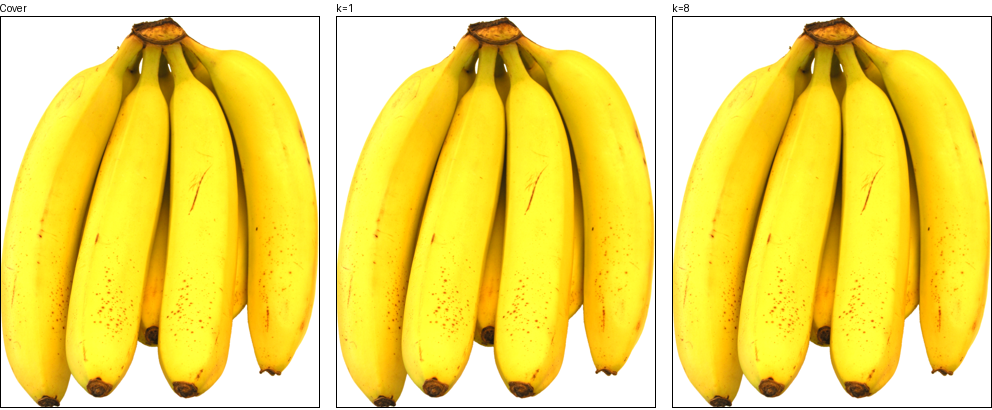

In [21]:
analysis_private_key: rsa.RSAPrivateKey
analysis_public_key: rsa.RSAPublicKey
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_receiver_private_key: rsa.RSAPrivateKey
analysis_receiver_public_key: rsa.RSAPublicKey
analysis_receiver_private_key, analysis_receiver_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_source = PngCarrier(sample_png_path)
with Image.open(sample_png_path) as analysis_cover_file:
    analysis_cover_array = np.asarray(analysis_cover_file, dtype=np.uint8).copy()
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
analysis_cover_source = PngCarrier(sample_png_path)
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        analysis_receiver_public_key,
        start_unit=bootstrap_span(analysis_receiver_public_key),
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key, analysis_receiver_private_key)
    with Image.open(analysis_output) as analysis_image_file:
        analysis_image = np.asarray(analysis_image_file, dtype=np.uint8).copy()
    analysis_output_source = PngCarrier(analysis_output)
    changed_values = 0
    for unit_start in range(0, analysis_cover_source.total_units, 65536):
        unit_count = min(65536, analysis_cover_source.total_units - unit_start)
        changed_values += int(np.count_nonzero(
            analysis_cover_source.read_units(unit_start, unit_count)
            != analysis_output_source.read_units(unit_start, unit_count)
        ))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count, analysis_layout.bootstrap_span)
    packet_bits = (analysis_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_bits": preserved,
        "bootstrap_bits_written": analysis_layout.bootstrap_span,
        "bootstrap_preserved_bits": 7 * analysis_layout.bootstrap_span,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append((analysis_preview, f"k={analysis_k}"))
for row in analysis_rows:
    print(row)
analysis_cover_preview = analysis_cover_image.copy()
analysis_cover_preview.thumbnail((320, 392))
print("Cover, k=1, and k=8, labelled and downscaled for display:")
display(show_panels([(analysis_cover_preview, "Cover"), *analysis_previews], scale=1))
del analysis_private_key, analysis_public_key, analysis_receiver_private_key, analysis_receiver_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_cover_preview

## Confidentiality from the protocol

Protocol version 3 encrypts and signs the complete payload record inside the library.
This directly satisfies the section 5 requirement for a custom payload that protects
confidentiality and integrity. The caller-side seal from the earlier demonstration
is removed under decision 16; its design remains recorded for comparison, but it is
no longer shown. The typed-payload demonstration keeps the MIME claim and original
filename in the existing metadata string, while the raw file bytes remain the user
payload.


## Typed payloads

The typed-payload demonstration stores the declared MIME type and original filename
as `key=value` entries in the existing metadata string, next to `kind` and `flow`.
The recovered `user_payload` is the raw file bytes. The receiver still sniffs those
bytes and checks the declared MIME type before rendering. Values cannot contain `;` or `=`;
the sender refuses such values because those characters delimit the metadata convention.
A receiver verifies first and interprets second: a failed verification has no payload to interpret.


P1: declared mime=text/plain, sniffed mime=None, agree=True, name=note.txt, body length=43, verdict=Authentic
The typed payload reached the text handler.


P2: declared mime=image/png, sniffed mime=image/png, agree=True, name=generated.png, body length=196, verdict=Authentic


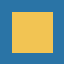

P3: declared mime=audio/wav, sniffed mime=audio/wav, agree=True, name=short-tone.wav, body length=4044, verdict=Authentic


N1: declared mime=image/png, sniffed mime=application/pdf, agree=False, name=not-really.png, body length=19, verdict=Authentic
Payload type mismatch; saved payload: handled-not-really.png
Reason: declared MIME 'image/png' does not match sniffed MIME 'application/pdf'


N2: sender declared mime=text/plain, sniffed mime=None, agree=True, sender name=../../etc/passwd, body length=19, verdict=Authentic
N2 rejected: ValueError name must be a safe bare filename


In [22]:
def sniff_mime(body: bytes) -> str | None:
    if body.startswith(b"\x89PNG"):
        return "image/png"
    if body.startswith(b"\xff\xd8\xff"):
        return "image/jpeg"
    if len(body) >= 12 and body[:4] == b"RIFF" and body[8:12] == b"WAVE":
        return "audio/wav"
    if body.startswith(b"%PDF"):
        return "application/pdf"
    return None


SNIFFABLE_MIMES = {"image/png", "image/jpeg", "audio/wav", "application/pdf"}


def mime_agrees(declared: str, body: bytes) -> bool:
    sniffed = sniff_mime(body)
    if sniffed is None:
        return declared not in SNIFFABLE_MIMES
    return sniffed == declared


def handle_payload(mime: str, name: str, body: bytes) -> None:
    safe_name = name.replace("/", "").replace("\\", "").replace("..", "")
    if safe_name in {"", "."}:
        safe_name = "payload.bin"
    output_path = DEMO_DIR / f"handled-{safe_name}"
    if not mime_agrees(mime, body):
        output_path.write_bytes(body)
        print("Payload type mismatch; saved payload:", output_path.name)
        print(f"Reason: declared MIME {mime!r} does not match sniffed MIME {sniff_mime(body)!r}")
        return
    if mime == "text/plain":
        try:
            print(body.decode("utf-8"))
        except UnicodeDecodeError as error:
            output_path.write_bytes(body)
            print("Invalid text payload; saved payload:", output_path.name)
            print("Reason:", type(error).__name__, str(error))
        return
    output_path.write_bytes(body)
    if mime in {"image/png", "image/jpeg"}:
        display(preview_image(output_path))
    elif mime in {"audio/wav", "audio/mpeg"}:
        display(Audio(filename=str(output_path)))
    else:
        print("Saved payload:", output_path.name)


content_receiver_public_key = receiver_public_key
content_sender_private_key: rsa.RSAPrivateKey
content_sender_public_key: rsa.RSAPublicKey
content_sender_private_key, content_sender_public_key = generate_rsa_keypair()

content_image_path = DEMO_DIR / "generated-content.png"
content_image = Image.new("RGB", (64, 64), (42, 116, 166))
content_image_draw = ImageDraw.Draw(content_image)
content_image_draw.rectangle((12, 12, 52, 52), fill=(242, 196, 83))
content_image.save(content_image_path, format="PNG")
content_image_body = content_image_path.read_bytes()

# This 4,000-sample tone is typed payload data, not the WAV cover.
# The WAV cover above contains 32,000 samples.
content_audio_samples = (
    128 + 80 * np.sin(2 * np.pi * 440 * np.arange(4000) / 8000)
).astype(np.uint8).tobytes()
content_audio_path = DEMO_DIR / "generated-content.wav"
with wave.open(str(content_audio_path), "wb") as content_audio_file:
    content_audio_file.setnchannels(1)
    content_audio_file.setsampwidth(1)
    content_audio_file.setframerate(8000)
    content_audio_file.writeframes(content_audio_samples)
# Replace this variable with bytes from a supplied WAV file later.
content_audio_body = content_audio_path.read_bytes()


def run_typed_case(
    label: str,
    declared_mime: str,
    name: str,
    body: bytes,
    stego_name: str,
) -> None:
    if ";" in declared_mime or "=" in declared_mime or ";" in name or "=" in name:
        raise ValueError("metadata values cannot contain ';' or '='")
    content_metadata = (
        f"kind=png;flow=typed-content;mime={declared_mime};name={name}"
    ).encode("utf-8")
    stego_path = DEMO_DIR / stego_name
    layout, _ = encode_png(
        sample_png_path,
        stego_path,
        content_sender_private_key,
        content_receiver_public_key,
        start_unit=bootstrap_span(content_receiver_public_key),
        lsb_count=1,
        user_payload=body,
        metadata=content_metadata,
    )
    result = verify_png(stego_path, content_sender_public_key, receiver_private_key)
    if not result.valid:
        print(f"{label}: verdict={result.verdict}, detail={result.detail}")
        return
    recovered_body = result.payload.user_payload
    try:
        metadata_fields = dict(
            item.split("=", 1)
            for item in result.payload.metadata.decode("utf-8").split(";")
            if "=" in item
        )
        recovered_mime = metadata_fields["mime"]
        recovered_name = metadata_fields["name"]
        if any(part in recovered_name for part in ("/", "\\", "..")):
            raise ValueError("name must be a safe bare filename")
    except (KeyError, UnicodeDecodeError, ValueError) as error:
        sniffed = sniff_mime(recovered_body)
        agrees = mime_agrees(declared_mime, recovered_body)
        print(
            f"{label}: sender declared mime={declared_mime}, sniffed mime={sniffed}, "
            f"agree={agrees}, sender name={name}, body length={len(recovered_body)}, "
            f"verdict={result.verdict}"
        )
        print(f"{label} rejected: {type(error).__name__} {error}")
        return
    sniffed = sniff_mime(recovered_body)
    agrees = mime_agrees(recovered_mime, recovered_body)
    print(
        f"{label}: declared mime={recovered_mime}, sniffed mime={sniffed}, "
        f"agree={agrees}, name={recovered_name}, body length={len(recovered_body)}, "
        f"verdict={result.verdict}"
    )
    handle_payload(recovered_mime, recovered_name, recovered_body)


run_typed_case(
    "P1",
    "text/plain",
    "note.txt",
    b"The typed payload reached the text handler.",
    "typed-text.png",
)
run_typed_case("P2", "image/png", "generated.png", content_image_body, "typed-image.png")
run_typed_case("P3", "audio/wav", "short-tone.wav", content_audio_body, "typed-audio.png")
run_typed_case(
    "N1",
    "image/png",
    "not-really.png",
    b"%PDF-1.7\nnot a PNG\n",
    "typed-negative-pdf.png",
)
run_typed_case(
    "N2",
    "text/plain",
    "../../etc/passwd",
    b"name rejection test",
    "typed-negative-name.png",
)


The metadata string is inside the library-encrypted record. An observer cannot
recover the packet location from protocol structure without the receiver private key.
A signed content type is still a claim by the sender, not a fact about the bytes;
software that renders the payload validates it first. The original filename is also
untrusted metadata: N2 refuses a non-bare name before the writing handler is called.
The 4,000-sample tone is typed payload data, not the 32,000-sample WAV cover.


## Payload file API demo

The rest of this notebook uses the unchanged bytes API: `encode_wav` and `verify_wav`.
The file API reads and writes payload data in chunks, so payload memory stays bounded.
The web application uses the file API and publishes a recovered file only after the
signature, GCM tag, record, and carrier hash pass.


In [23]:
import hashlib
import time
import tracemalloc

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while chunk := file.read(64 * 1024):
            digest.update(chunk)
    return digest.hexdigest()

cell_started = time.perf_counter()
streamed_payload_size = 4 * 1024 * 1024
streamed_frames = 52 * 44_100
streamed_cover_path = DEMO_DIR / "payload-stream-cover.wav"
streamed_stego_path = DEMO_DIR / "payload-stream-stego.wav"
streamed_payload_input = DEMO_DIR / "random-payload.bin"
streamed_payload_output = DEMO_DIR / "random-payload-recovered.bin"
with wave.open(str(streamed_cover_path), "wb") as wav_file:
    wav_file.setnchannels(2)
    wav_file.setsampwidth(2)
    wav_file.setframerate(44_100)
    for frame_start in range(0, streamed_frames, 16_384):
        frame_count = min(16_384, streamed_frames - frame_start)
        wav_file.writeframesraw(os.urandom(frame_count * 4))
with streamed_payload_input.open("wb") as payload_file:
    for payload_offset in range(0, streamed_payload_size, 64 * 1024):
        payload_file.write(os.urandom(min(64 * 1024, streamed_payload_size - payload_offset)))

try:
    tracemalloc.start()
    streamed_layout, streamed_record = encode_wav_from_payload_path(
        streamed_cover_path, streamed_stego_path, content_sender_private_key,
        content_receiver_public_key, bootstrap_span(content_receiver_public_key), 8,
        streamed_payload_input,
        b"kind=payload;flow=file-api;mime=application/octet-stream;name=random-payload.bin",
    )
    streamed_result = verify_wav_to_payload_path(
        streamed_stego_path, content_sender_public_key, receiver_private_key,
        streamed_payload_output,
    )
    _, streamed_peak_bytes = tracemalloc.get_traced_memory()
finally:
    tracemalloc.stop()

streamed_hashes_match = file_sha256(streamed_payload_input) == file_sha256(streamed_payload_output)
streamed_no_staging = not any(DEMO_DIR.glob(".stego-staging-*"))
print("File API verdict:", streamed_result.verdict)
print(f"Payload: {streamed_record.user_payload_size / (1024 * 1024):.1f} MiB, traced peak: {streamed_peak_bytes / (1024 * 1024):.2f} MiB")
print("Recovered payload file:", streamed_result.payload_path.name)
print("Recovered SHA-256 matches:", streamed_hashes_match)
print("No staging directories left:", streamed_no_staging)
for temporary_path in (streamed_cover_path, streamed_stego_path, streamed_payload_input, streamed_payload_output):
    temporary_path.unlink(missing_ok=True)
print(f"Cell elapsed: {time.perf_counter() - cell_started:.2f} s")

File API verdict: Authentic
Payload: 4.0 MiB, traced peak: 6.14 MiB
Recovered payload file: random-payload-recovered.bin
Recovered SHA-256 matches: True
No staging directories left: True
Cell elapsed: 0.08 s


### Required-case coverage

The notebook demonstrates positive PNG and WAV cases; altered PNG and WAV cases;
wrong sender and receiver keys; pristine-carrier, wrong-location, decryption, and
malformed-bootstrap verdicts; the capacity refusals; the A-to-B receiver-key story;
multiple payload sizes through the typed cases; and selectable `k` values in the
analysis and tests. The team's final message choices and FR13 innovation statement
remain undecided. A live email or folder transfer is still a presentation task, not
simulated by this notebook.

## Clean up

Generated files live in the temporary directory and are removed now.

In [24]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.


## Optional video challenge

Video is an optional challenge. Media code **3** uses the `VID-` prefix. Carrier units are RGB frame bytes, then audio low bytes. Fixed data includes frame ticks, audio start, and audio high bytes. The output is lossless FFV1 video and PCM audio in Matroska (`.mkv`). Credit: Sitt Min Naing, commit `c56e0ea`.


In [25]:
import av
from fractions import Fraction
from tempfile import TemporaryDirectory

video_demo_temp = TemporaryDirectory(prefix="inf2005-video-")
video_demo_dir = Path(video_demo_temp.name)
video_source_path = video_demo_dir / "moving-tone.mp4"
video_height, video_width, video_rate = 360, 640, 30
video_duration_seconds = 5
video_frame_count = video_rate * video_duration_seconds
video_audio_rate = 48_000
video_audio_frames = video_audio_rate * video_duration_seconds

y_grid, x_grid = np.indices((video_height, video_width), dtype=np.uint16)
with av.open(str(video_source_path), mode="w", format="mp4") as output:
    video_stream = output.add_stream("libx264", rate=video_rate)
    video_stream.width = video_width
    video_stream.height = video_height
    video_stream.pix_fmt = "yuv420p"
    video_stream.time_base = Fraction(1, video_rate)
    video_stream.codec_context.time_base = Fraction(1, video_rate)
    video_stream.codec_context.options = {"preset": "ultrafast", "crf": "28"}
    audio_stream = output.add_stream("aac", rate=video_audio_rate)
    audio_stream.layout = "stereo"
    audio_stream.time_base = Fraction(1, video_audio_rate)

    for frame_index in range(video_frame_count):
        rgb = np.empty((video_height, video_width, 3), dtype=np.uint8)
        rgb[:, :, 0] = (x_grid + frame_index * 7) % 256
        rgb[:, :, 1] = (y_grid * 3 + frame_index * 11) % 256
        rgb[:, :, 2] = (x_grid + y_grid + frame_index * 13) % 256
        frame = av.VideoFrame.from_ndarray(rgb, format="rgb24")
        frame.pts = frame_index
        frame.time_base = Fraction(1, video_rate)
        for packet in video_stream.encode(frame):
            output.mux(packet)

    for sample_start in range(0, video_audio_frames, 1024):
        sample_end = min(sample_start + 1024, video_audio_frames)
        positions = np.arange(sample_start, sample_end, dtype=np.float64)
        samples = np.stack((
            np.sin(2 * np.pi * 440 * positions / video_audio_rate),
            np.sin(2 * np.pi * 660 * positions / video_audio_rate),
        ), axis=1)
        audio_frame = av.AudioFrame.from_ndarray(
            (samples * 12_000).astype(np.int16).reshape(1, -1),
            format="s16", layout="stereo"
        )
        audio_frame.sample_rate = video_audio_rate
        audio_frame.pts = sample_start
        audio_frame.time_base = Fraction(1, video_audio_rate)
        for packet in audio_stream.encode(audio_frame):
            output.mux(packet)
    for stream in (video_stream, audio_stream):
        for packet in stream.encode():
            output.mux(packet)

print(f"Generated clip: {video_source_path.name} ({video_duration_seconds} seconds, H.264 + stereo AAC)")


Generated clip: moving-tone.mp4 (5 seconds, H.264 + stereo AAC)


In [26]:
video_source = VideoCarrier(video_source_path)
(video_width_seen, video_height_seen, video_frames_seen,
 video_rate_seen, video_channels_seen, audio_frames_seen) = struct.unpack(
    ">IIQIHQ", video_source.media_context
)
print(f"Width × height: {video_width_seen} × {video_height_seen}")
print("Video frames:", video_frames_seen)
print(f"Audio: {video_rate_seen} Hz, {video_channels_seen} channels, {audio_frames_seen} frames per channel")
print("Total units:", video_source.total_units)
print("Fixed-byte count:", video_source.fixed_byte_count)
print("Context hex:", video_source.media_context.hex())
video_source.close()


Width × height: 640 × 360
Video frames: 150
Audio: 48000 Hz, 2 channels, 240640 frames per channel
Total units: 104161280
Fixed-byte count: 482488
Context hex: 000002800000016800000000000000960000bb800002000000000003ac00


In [27]:
video_payload = b"A short video carrier demonstration."
video_output_path = video_demo_dir / "moving-tone-stego.mkv"
video_started = time.perf_counter()
video_layout, video_payload_record = encode_video(
    video_source_path,
    video_output_path,
    content_sender_private_key,
    content_receiver_public_key,
    bootstrap_span(content_receiver_public_key),
    3,
    video_payload,
    b"kind=video;flow=notebook",
)
video_encode_seconds = time.perf_counter() - video_started
video_encoded_bytes = video_output_path.stat().st_size
print("Layout:", video_layout)
print("Input bytes:", video_source_path.stat().st_size)
print("Output bytes:", video_encoded_bytes)
print(f"Output/input size ratio: {video_encoded_bytes / video_source_path.stat().st_size:.2f}×")
print(f"Encode time: {video_encode_seconds:.2f} s")
video_verify_started = time.perf_counter()
video_authentic_result = verify_video(
    video_output_path, content_sender_public_key, receiver_private_key
)
video_verify_seconds = time.perf_counter() - video_verify_started
print("Video verdict:", video_authentic_result.verdict)
print("Recovered payload matches:", video_authentic_result.payload.user_payload == video_payload)
print(f"Verify time: {video_verify_seconds:.2f} s")
assert video_authentic_result.verdict == "Authentic"
assert video_authentic_result.payload.user_payload == video_payload
video_verdicts = {"Authentic carrier": video_authentic_result.verdict}


Layout: EmbeddingLayout(total_units=104161280, start_unit=2048, footprint=1176, lsb_count=3, ciphertext_length=185, pad_bits=0, bootstrap_span=2048)
Input bytes: 699923
Output bytes: 23004008
Output/input size ratio: 32.87×
Encode time: 0.70 s


Video verdict: Authentic
Recovered payload matches: True
Verify time: 0.35 s


In [28]:
def rewrite_video_demo(source_path: Path, output_path: Path, change: str | None = None) -> None:
    """Make a lossless FFV1/PCM copy with at most one controlled change."""
    with av.open(str(source_path)) as source:
        video_in, audio_in = source.streams.video[0], source.streams.audio[0]
        audio_rate = audio_in.codec_context.sample_rate
        audio_layout = audio_in.codec_context.layout.name
        with av.open(str(output_path), mode="w", format="matroska") as output:
            video_out = output.add_stream("ffv1", rate=video_rate)
            video_out.width = video_in.codec_context.width
            video_out.height = video_in.codec_context.height
            video_out.pix_fmt = "bgr0"
            video_out.time_base = Fraction(1, 1000)
            video_out.codec_context.time_base = Fraction(1, 1000)
            audio_out = output.add_stream("pcm_s16le", rate=audio_rate)
            audio_out.layout = audio_layout

            for frame_index, frame in enumerate(source.decode(video=0)):
                rgb = frame.to_ndarray(format="rgb24")
                if change == "pixel-lsb" and frame_index == 5:
                    rgb[0, 0, 0] ^= np.uint8(1)
                rewritten = av.VideoFrame.from_ndarray(rgb, format="rgb24")
                rewritten.pts = frame.pts + (1 if change == "timestamp" and frame_index == 3 else 0)
                rewritten.time_base = frame.time_base or video_in.time_base
                for packet in video_out.encode(rewritten):
                    output.mux(packet)

            source.seek(0)
            for frame_index, frame in enumerate(source.decode(audio=0)):
                values = frame.to_ndarray().copy()
                if change in {"audio-low", "audio-high"} and frame_index == 5 and values.size:
                    bit = 1 if change == "audio-low" else 0x0100
                    values.reshape(-1)[0] ^= np.int16(bit)
                rewritten_audio = av.AudioFrame.from_ndarray(
                    values, format="s16", layout=audio_layout
                )
                rewritten_audio.sample_rate = frame.sample_rate
                rewritten_audio.pts = frame.pts
                rewritten_audio.time_base = frame.time_base
                for packet in audio_out.encode(rewritten_audio):
                    output.mux(packet)
            for stream in (video_out, audio_out):
                for packet in stream.encode():
                    output.mux(packet)


In [29]:
video_tamper_cases = (
    ("Pixel LSB", "pixel-lsb"),
    ("Audio low byte", "audio-low"),
    ("Audio high byte", "audio-high"),
    ("Frame timestamp", "timestamp"),
)
for label, change in video_tamper_cases:
    changed_path = video_demo_dir / f"{change}.mkv"
    rewrite_video_demo(video_output_path, changed_path, change)
    changed_result = verify_video(
        changed_path, content_sender_public_key, receiver_private_key
    )
    video_verdicts[label] = changed_result.verdict
    print(f"{label}: {changed_result.verdict}")
    assert changed_result.verdict == "Tampered", changed_result.detail


Pixel LSB: Tampered


Audio low byte: Tampered


Audio high byte: Tampered


Frame timestamp: Tampered


In [30]:
video_title_path = video_demo_dir / "title-changed.mkv"
with av.open(str(video_output_path)) as source, av.open(
    str(video_title_path), mode="w", format="matroska"
) as output:
    output.metadata["title"] = "Changed title only"
    output_streams = {
        stream.index: output.add_stream_from_template(stream)
        for stream in source.streams
    }
    for packet in source.demux():
        if packet.dts is None:
            continue
        packet.stream = output_streams[packet.stream.index]
        output.mux(packet)
video_title_result = verify_video(
    video_title_path, content_sender_public_key, receiver_private_key
)
video_verdicts["Changed title tag"] = video_title_result.verdict
print("Changed Matroska title tag:", video_title_result.verdict)
assert video_title_result.verdict == "Authentic"


Changed Matroska title tag: Authentic


Tags, rotation, colour metadata, and other tracks are outside the authenticity boundary. A title change does not change the decoded carrier. The carrier checks frame and audio data, not every container field.


In [31]:
video_lossy_path = video_demo_dir / "lossy-h264-aac.mkv"
with av.open(str(video_output_path)) as source, av.open(
    str(video_lossy_path), mode="w", format="matroska"
) as output:
    source_video, source_audio = source.streams.video[0], source.streams.audio[0]
    lossy_video = output.add_stream("libx264", rate=video_rate)
    lossy_video.width = source_video.codec_context.width
    lossy_video.height = source_video.codec_context.height
    lossy_video.pix_fmt = "yuv420p"
    lossy_video.codec_context.options = {"preset": "ultrafast", "crf": "28"}
    lossy_audio = output.add_stream("aac", rate=source_audio.codec_context.sample_rate)
    lossy_audio.layout = "stereo"
    for frame in source.decode(video=0):
        for packet in lossy_video.encode(frame):
            output.mux(packet)
    for packet in lossy_video.encode():
        output.mux(packet)
    source.seek(0)
    for frame in source.decode(audio=0):
        for packet in lossy_audio.encode(frame):
            output.mux(packet)
    for packet in lossy_audio.encode():
        output.mux(packet)
video_lossy_result = verify_video(
    video_lossy_path, content_sender_public_key, receiver_private_key
)
video_verdicts["Lossy H.264/AAC re-encode"] = video_lossy_result.verdict
print("Lossy H.264/AAC re-encode:", video_lossy_result.verdict)
assert video_lossy_result.verdict != "Authentic"


Lossy H.264/AAC re-encode: Cannot Verify


In [32]:
video_extra_audio_path = video_demo_dir / "extra-audio.mkv"
with av.open(str(video_output_path)) as source, av.open(
    str(video_extra_audio_path), mode="w", format="matroska"
) as output:
    input_video, input_audio = source.streams.video[0], source.streams.audio[0]
    output_streams = {
        input_video.index: output.add_stream_from_template(input_video),
        input_audio.index: output.add_stream_from_template(input_audio),
    }
    second_audio = output.add_stream(
        "pcm_s16le", rate=input_audio.codec_context.sample_rate
    )
    second_audio.layout = input_audio.codec_context.layout.name
    for packet in source.demux(input_video, input_audio):
        if packet.dts is None:
            continue
        packet.stream = output_streams[packet.stream.index]
        output.mux(packet)
    source.seek(0)
    for frame in source.decode(audio=0):
        for packet in second_audio.encode(frame):
            output.mux(packet)
    for packet in second_audio.encode():
        output.mux(packet)
try:
    VideoCarrier(video_extra_audio_path)
except ValueError as error:
    video_refusal = str(error)
    print("Additional-stream refusal:", video_refusal)
    assert "unsupported additional stream" in video_refusal
else:
    raise AssertionError("a second audio stream must be refused")
video_verdicts["Second audio stream"] = "Refused"


Additional-stream refusal: unsupported additional stream


### Limits and cost

The limits are **4 GiB (4 × 1024³) decoded carrier units**, at most **178,956,970 pixels per decoded frame** (Pillow's PNG decompression-bomb error threshold), mono or stereo audio, **2 GiB** output, and **3 GiB** free space. There is no duration or frame-count cap. The unit budget is about **690 1080p frames** (about **23 seconds at 30 fps** or **11.5 seconds at 60 fps**). At this 1080p maximum, measured content produces about **900 MB** of FFV1 output, so the 2 GiB cap leaves room for detailed or noisy content. See the [design note](../AGENT_docs/VIDEO-CARRIER-DESIGN.md#output-and-limits) for other resolutions and implementation details. In the design-note 5-second 1080p30 run, encode took **6.677 s**, verify took **2.838 s**, peak RSS was **888,560 KiB**, and output was **197,180,817 bytes**. A 640×360 RSS test used **189,036 KiB** at 5 seconds and **211,024 KiB** at 15 seconds. FFV1/PCM output is much larger than compressed H.264/AAC; the design-note example grew from 5,019,557 bytes to 197,180,817 bytes (about **39×**). Lossless FFV1/PCM survives. Lossy re-encoding does not.


In [33]:
print("| Video case | Result |")
print("| --- | --- |")
for label, verdict in video_verdicts.items():
    print(f"| {label} | {verdict} |")


| Video case | Result |
| --- | --- |
| Authentic carrier | Authentic |
| Pixel LSB | Tampered |
| Audio low byte | Tampered |
| Audio high byte | Tampered |
| Frame timestamp | Tampered |
| Changed title tag | Authentic |
| Lossy H.264/AAC re-encode | Cannot Verify |
| Second audio stream | Refused |


In [34]:
video_source.close()
video_demo_temp.cleanup()
print("Temporary video demonstration files removed.")


Temporary video demonstration files removed.
